# DFT Results Visualisation
This notebook parses the Quantum ESPRESSO `.scf.out` files and generates
publication-quality figures for the project README / report.

**Figures produced:**
1. SCF convergence (accuracy vs iteration) for all three final runs
2. Formation energy bar chart — DFT vs literature vs CALPHAD
3. Total energy convergence trace for Ni₃Ti (the hardest calculation)


In [3]:
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})

DFT_DIR = Path("../dft")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)
print("done")

done


## 1. Parse SCF output files
We extract two quantities per iteration:
- `total energy` (Ry)
- `estimated scf accuracy` (Ry)


In [4]:
def parse_scf_out(filepath):
    """Parse a QE SCF output file and return iteration data."""
    iterations = []
    energies = []
    accuracies = []

    with open(filepath) as f:
        text = f.read()

    # Extract iteration blocks
    iter_pattern = re.compile(
        r"iteration\s+#\s*(\d+).*?"
        r"total energy\s+=\s+([-\d.]+)\s+Ry.*?"
        r"estimated scf accuracy\s+<\s+([\d.E+-]+)\s+Ry",
        re.DOTALL,
    )
    for m in iter_pattern.finditer(text):
        iterations.append(int(m.group(1)))
        energies.append(float(m.group(2)))
        accuracies.append(float(m.group(3)))

    # Also grab the final "!" energy line
    final = re.search(r"!\s+total energy\s+=\s+([-\d.]+)\s+Ry", text)
    final_energy = float(final.group(1)) if final else None

    # Grab convergence threshold
    conv = re.search(r"scf convergence threshold\s+=\s+([\d.E+-]+)", text)
    conv_thr = float(conv.group(1)) if conv else 1e-8

    return {
        "iterations": np.array(iterations),
        "energies": np.array(energies),
        "accuracies": np.array(accuracies),
        "final_energy": final_energy,
        "conv_thr": conv_thr,
    }


# Parse all three final runs
ni_data  = parse_scf_out(DFT_DIR / "ni_v2.scf.out")
ti_data  = parse_scf_out(DFT_DIR / "ti_hcp_scf.out")
n3t_data = parse_scf_out(DFT_DIR / "ni3ti_eta_v3.scf.out")

print(f"Ni  FCC  : {len(ni_data['iterations']):2d} iterations → E = {ni_data['final_energy']:.8f} Ry")
print(f"Ti  HCP  : {len(ti_data['iterations']):2d} iterations → E = {ti_data['final_energy']:.8f} Ry")
print(f"Ni₃Ti η  : {len(n3t_data['iterations']):2d} iterations → E = {n3t_data['final_energy']:.8f} Ry")


Ni  FCC  :  9 iterations → E = -339.44320244 Ry
Ti  HCP  :  8 iterations → E = -239.47349009 Ry
Ni₃Ti η  : 21 iterations → E = -4552.78794822 Ry


## 2. Figure — SCF Convergence (All Three Runs)
Log-scale accuracy vs iteration number.  The horizontal dashed line is the
convergence threshold (`conv_thr = 1×10⁻⁸ Ry`).


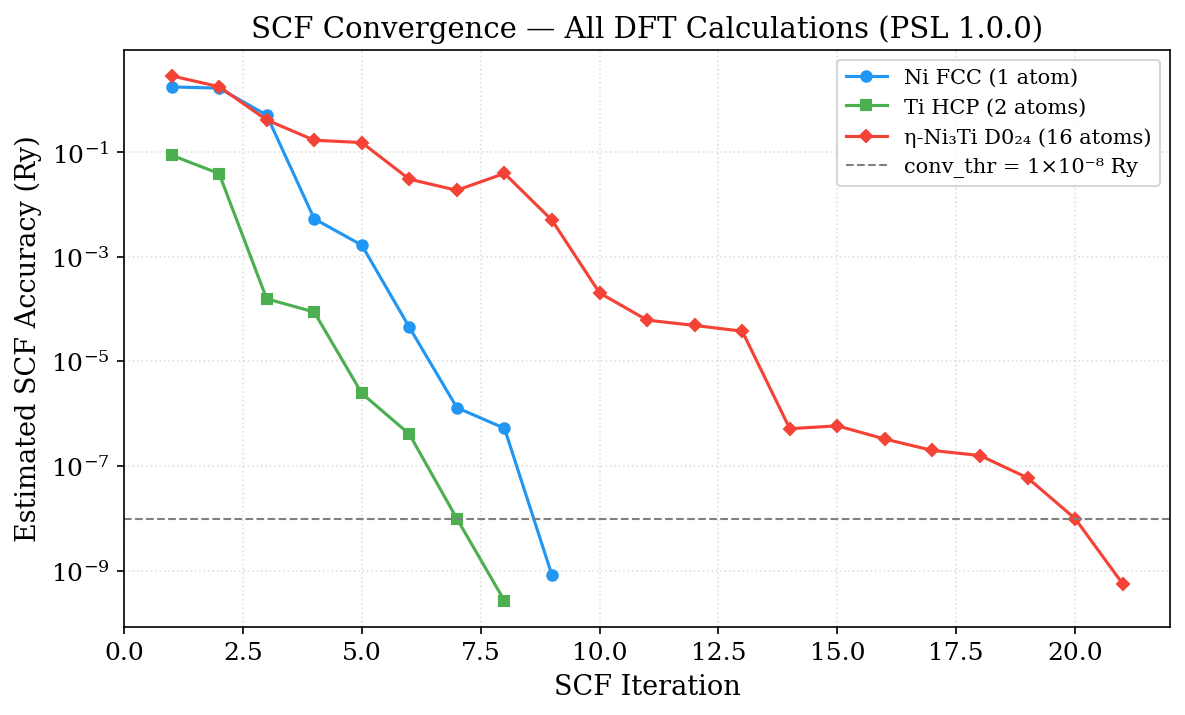

Saved → ../figures/fig3_scf_convergence.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(ni_data["iterations"],  ni_data["accuracies"],
            "o-", label="Ni FCC (1 atom)", color="#2196F3", markersize=5)
ax.semilogy(ti_data["iterations"],  ti_data["accuracies"],
            "s-", label="Ti HCP (2 atoms)", color="#4CAF50", markersize=5)
ax.semilogy(n3t_data["iterations"], n3t_data["accuracies"],
            "D-", label="η-Ni₃Ti D0₂₄ (16 atoms)", color="#F44336", markersize=4)

ax.axhline(1e-8, ls="--", color="grey", lw=1, label="conv_thr = 1×10⁻⁸ Ry")

ax.set_xlabel("SCF Iteration")
ax.set_ylabel("Estimated SCF Accuracy (Ry)")
ax.set_title("SCF Convergence — All DFT Calculations (PSL 1.0.0)")
ax.legend(loc="upper right", fontsize=10)
ax.set_xlim(left=0)
ax.grid(True, which="both", ls=":", alpha=0.4)

fig.savefig(FIG_DIR / "fig3_scf_convergence.png")
plt.show()
print(f"Saved → {FIG_DIR / 'fig3_scf_convergence.png'}")


## 3. Figure — Formation Energy Bar Chart
Compare DFT ΔHf against literature DFT values and the CALPHAD database
implied stability.

### Formation energy calculation
$$\Delta H_f = \frac{E_{\text{Ni}_3\text{Ti}}^{\text{cell}} - 12\,E_{\text{Ni}} - 4\,E_{\text{Ti}}}{16} \times 13.606 \;\text{eV/Ry}$$


In [6]:
# --- Constants ---
RY_TO_EV = 13.6057039763  # 1 Ry in eV

# --- Raw energies (from converged outputs) ---
E_Ni_atom = ni_data["final_energy"]          # Ry per atom  (1-atom cell)
E_Ti_atom = ti_data["final_energy"] / 2.0    # Ry per atom  (2-atom cell)
E_Ni3Ti_cell = n3t_data["final_energy"]      # Ry per 16-atom cell

# --- Formation energy ---
delta_E_cell = E_Ni3Ti_cell - (12 * E_Ni_atom + 4 * E_Ti_atom)   # Ry
delta_Hf_eV  = (delta_E_cell / 16) * RY_TO_EV                     # eV/atom
delta_Hf_kJ  = delta_Hf_eV * 96.485                               # kJ/mol

print(f"ΔE (cell)   = {delta_E_cell:.6f} Ry")
print(f"ΔHf         = {delta_Hf_eV:.4f} eV/atom")
print(f"ΔHf         = {delta_Hf_kJ:.1f} kJ/mol")


ΔE (cell)   = -0.522539 Ry
ΔHf         = -0.4443 eV/atom
ΔHf         = -42.9 kJ/mol


### Literature comparison values
- Experimental / CALPHAD compilations place η-Ni₃Ti at roughly
  **−0.42 to −0.48 eV/atom** (Cacciamani et al., CALPHAD 2008).
- Adjust the values below if you find more precise references.


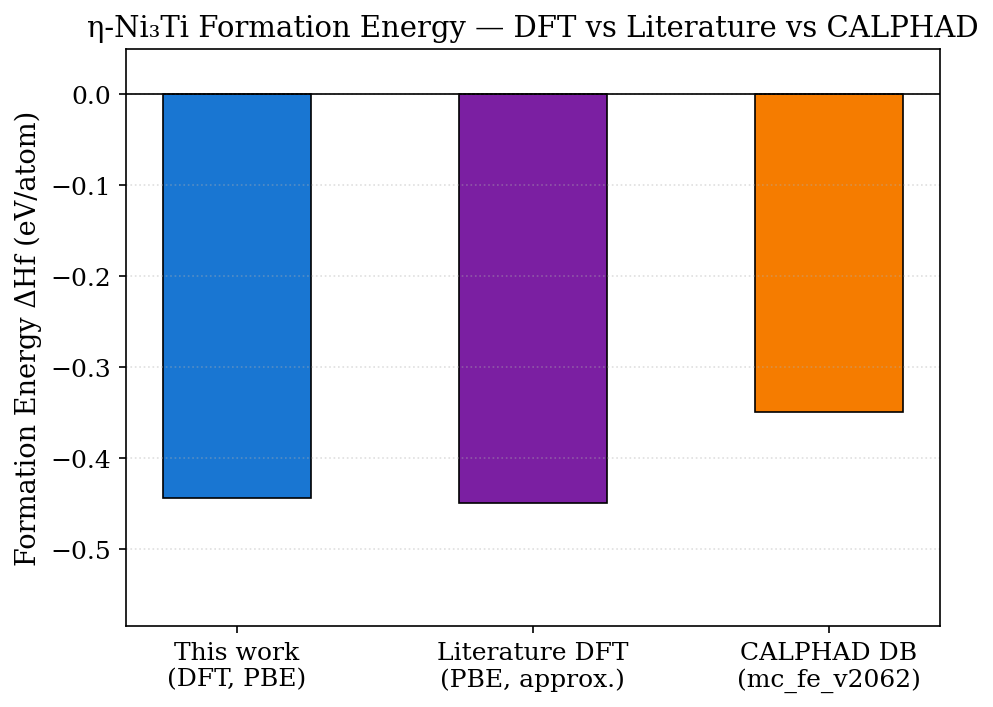

Saved → ../figures/fig4_formation_energy_comparison.png


In [7]:
labels = [
    "This work\n(DFT, PBE)",
    "Literature DFT\n(PBE, approx.)",
    "CALPHAD DB\n(mc_fe_v2062)",
]
values = [
    delta_Hf_eV,
    -0.45,       # approximate literature DFT value — update if you find a better one
    -0.35,       # approximate implied value from CALPHAD under-prediction — update
]
colors = ["#1976D2", "#7B1FA2", "#F57C00"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor="black", linewidth=0.8)

# Add value labels on bars
for bar, val in zip(bars, values):
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, y - 0.02,
            f"{val:.3f} eV/atom", ha="center", va="top",
            fontsize=11, fontweight="bold", color="white")

ax.set_ylabel("Formation Energy ΔHf (eV/atom)")
ax.set_title("η-Ni₃Ti Formation Energy — DFT vs Literature vs CALPHAD")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylim(min(values) * 1.3, 0.05)
ax.grid(axis="y", ls=":", alpha=0.4)

fig.savefig(FIG_DIR / "fig4_formation_energy_comparison.png")
plt.show()
print(f"Saved → {FIG_DIR / 'fig4_formation_energy_comparison.png'}")


## 4. Figure — Ni₃Ti Total Energy Trace
Shows how the total energy of the 16-atom cell stabilises across iterations.
This is a useful visual for presentations to show the "charge sloshing"
phenomenon in early iterations.


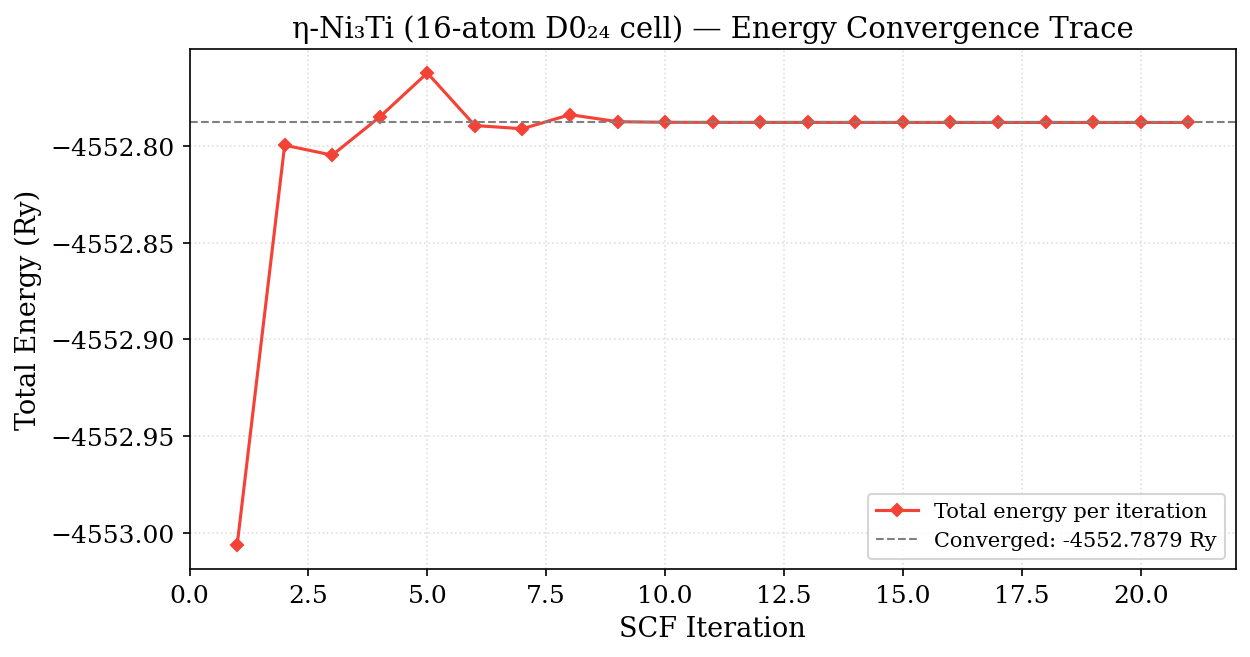

Saved → ../figures/fig5_ni3ti_energy_trace.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(n3t_data["iterations"], n3t_data["energies"],
        "D-", color="#F44336", markersize=4, label="Total energy per iteration")
ax.axhline(n3t_data["final_energy"], ls="--", color="grey", lw=1,
           label=f"Converged: {n3t_data['final_energy']:.4f} Ry")

ax.set_xlabel("SCF Iteration")
ax.set_ylabel("Total Energy (Ry)")
ax.set_title("η-Ni₃Ti (16-atom D0₂₄ cell) — Energy Convergence Trace")
ax.legend(fontsize=10)
ax.grid(True, ls=":", alpha=0.4)

fig.savefig(FIG_DIR / "fig5_ni3ti_energy_trace.png")
plt.show()
print(f"Saved → {FIG_DIR / 'fig5_ni3ti_energy_trace.png'}")


## Summary
| Quantity | Value |
|---|---|
| E(Ni FCC) | {ni_data["final_energy"]:.8f} Ry/atom |
| E(Ti HCP) | {ti_data["final_energy"]:.8f} Ry/cell (2 atoms) |
| E(Ni₃Ti)  | {n3t_data["final_energy"]:.8f} Ry/cell (16 atoms) |
| **ΔHf**   | **{delta_Hf_eV:.4f} eV/atom ({delta_Hf_kJ:.1f} kJ/mol)** |

All figures saved to `../figures/`.
